# Retail Customer Behavior & RFM Analysis

# 1.Introduction

In [1]:
# Objective:
# To segment customers based on purchasing behavior

# Week 1

# 2. Import Libraries

In [2]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

import time

# Advanced visualization & layouts
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap

# Interactive visualization
from matplotlib import colors as mcolors

In [3]:
# Initialize Plotly for use in the notebook
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

# 3. Load Dataset

In [4]:
# Load dataset
df = pd.read_excel("Online Retail.xlsx") 

# 4. Data Understanding

In [5]:
# Display dataset
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [6]:
# View first 10 rows
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# Check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
# Basic statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
# Top countries
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [12]:
# Check duplicate rows
df.duplicated().sum()

np.int64(5268)

In [13]:
# Check date range
df['InvoiceDate'].min(), df['InvoiceDate'].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [14]:
# Quick revenue understanding
(df['Quantity'] * df['UnitPrice']).describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
dtype: float64

In [15]:
# Counting the country
df['Country'].value_counts().head()

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

In [16]:
# Unique customers
df['CustomerID'].nunique()

4372

In [17]:
# Check invoice frequency
df['InvoiceNo'].value_counts()

InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
554023        1
554022        1
554021        1
554020        1
C558901       1
Name: count, Length: 25900, dtype: int64

In [18]:
# Check cancelled invoices (starting with 'C')
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [19]:
# Analyze quantity of cancelled orders
df[df['InvoiceNo'].astype(str).str.startswith('C')]['Quantity'].describe()

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [20]:
# Count unique product descriptions
df['Description'].nunique()

4223

In [21]:
# Get top 60 most frequent product descriptions
df['Description'].value_counts().head(60)

Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
ASSORTED COLOUR BIRD ORNAMENT          1501
SET OF 3 CAKE TINS PANTRY DESIGN       1473
PACK OF 72 RETROSPOT CAKE CASES        1385
LUNCH BAG  BLACK SKULL.                1350
NATURAL SLATE HEART CHALKBOARD         1280
POSTAGE                                1252
JUMBO BAG PINK POLKADOT                1251
HEART OF WICKER SMALL                  1237
JAM MAKING SET WITH JARS               1229
JUMBO STORAGE BAG SUKI                 1214
PAPER CHAIN KIT 50'S CHRISTMAS         1210
JUMBO SHOPPER VINTAGE RED PAISLEY      1202
LUNCH BAG CARS BLUE                    1197
LUNCH BAG SPACEBOY DESIGN              1192
JAM MAKING SET PRINTED                 1182
RECIPE BOX PANTRY YELLOW DESIGN        1180
SPOTTY BUNTING                         1172
LUNCH BAG SUKI DESIG

In [22]:
# Get last 60 most frequent product descriptions
df['Description'].value_counts().tail(60)

Description
damaged stock                          1
broken                                 1
throw away                             1
Had been put aside.                    1
Wet pallet-thrown away                 1
wrongly sold (22719) barcode           1
BIG POLKADOT MUG                       1
BLUE FLYING SINGING CANARY             1
HEN HOUSE W CHICK IN NEST              1
WIRE FLOWER T-LIGHT HOLDER             1
mouldy                                 1
S/4 BLACK DISCO PARTITION PANEL        1
RUBY GLASS NECKLACE 42"                1
wrong barcode                          1
barcode problem                        1
 I LOVE LONDON MINI RUCKSACK           1
SET 10 CARDS 12 DAYS OF XMAS 17059     1
ZINC PLANT POT HOLDER                  1
POLYESTER FILLER PAD 60x40cm           1
LASER CUT MULTI STRAND NECKLACE        1
72 CAKE CASES VINTAGE CHRISTMAS        1
HAYNES CAMPER SHOULDER BAG             1
PINK FLOCK PHOTO FRAME                 1
damages/showroom etc                   1
samp

In [23]:
# Get rows with '?' in Description
df[df['Description'].str.contains(r'\?', na=False)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
7313,537032,21275,?,-30,2010-12-03 16:50:00,0.0,NaN,United Kingdom
21518,538090,20956,?,-723,2010-12-09 14:48:00,0.0,NaN,United Kingdom
38261,539494,21479,?,752,2010-12-20 10:36:00,0.0,NaN,United Kingdom
43662,540100,22837,?,-106,2011-01-04 16:53:00,0.0,NaN,United Kingdom
50806,540558,21258,?,-29,2011-01-10 10:04:00,0.0,NaN,United Kingdom


# 5.SQL Data Cleaning

In [24]:
# importing sqlite3 for Data cleaning
import sqlite3

# Create SQLite database connection
conn = sqlite3.connect("retail.db")

# Store data into SQL table
df.to_sql("retail", conn, if_exists="replace", index=False)

541909

In [25]:
# Get top 50 most frequent product descriptions from database
query = """
SELECT Description, COUNT(*) as count
FROM retail
GROUP BY Description
ORDER BY count DESC
LIMIT 50
"""
pd.read_sql(query, conn)


,Description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2369
1,REGENCY CAKESTAND 3 TIER,2200
2,JUMBO BAG RED RETROSPOT,2159
3,PARTY BUNTING,1727
4,LUNCH BAG RED RETROSPOT,1638
5,ASSORTED COLOUR BIRD ORNAMENT,1501
6,SET OF 3 CAKE TINS PANTRY DESIGN,1473
7,None,1454
8,PACK OF 72 RETROSPOT CAKE CASES,1385
9,LUNCH BAG BLACK SKULL.,1350


In [26]:
# Get descriptions containing '?' and their counts
query = """
SELECT Description, COUNT(*)
FROM retail
WHERE Description LIKE '%?%'
GROUP BY Description
"""
pd.read_sql(query, conn)

,Description,COUNT(*)
0,?,47
1,? sold as sets?,1
2,??,7
3,?? missing,1
4,???,1
5,????damages????,1
6,????missing,1
7,???lost,1
8,???missing,2
9,?display?,1


In [27]:
# Clean and filter retail data by removing invalid, cancelled, and unwanted records

query = """
SELECT
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    ROUND(Quantity * UnitPrice, 2) AS TotalPrice
FROM retail
WHERE
    -- Remove cancelled orders
    InvoiceNo NOT LIKE 'C%'

    -- Remove missing customers
    AND CustomerID IS NOT NULL

    -- Remove invalid values
    AND Quantity > 0
    AND UnitPrice > 0

    -- Clean descriptions
    AND Description IS NOT NULL
    AND TRIM(Description) != ''
    AND Description NOT LIKE '%?%'

    -- Remove unwanted/system entries (ONLY NOT LIKE)
    AND LOWER(Description) NOT LIKE '%damaged%'
    AND LOWER(Description) NOT LIKE '%faulty%'
    AND LOWER(Description) NOT LIKE '%adjustment%'
    AND LOWER(Description) NOT LIKE '%postage%'
    AND LOWER(Description) NOT LIKE '%amazon%'
    AND LOWER(Description) NOT LIKE '%dotcom%'
    AND LOWER(Description) NOT LIKE '%check%'
    AND LOWER(Description) NOT LIKE '%found%'
    AND LOWER(Description) NOT LIKE '%mailout%'
    AND LOWER(Description) NOT LIKE '%stock%'
    AND LOWER(Description) NOT LIKE '%website%'
    AND LOWER(Description) NOT LIKE '%damag%'
    AND LOWER(Description) NOT LIKE '%fault%'
    AND LOWER(Description) NOT LIKE '%adjust%'
    AND LOWER(Description) NOT LIKE '%test%'
    AND LOWER(Description) NOT LIKE '%crush%'
    AND LOWER(Description) NOT LIKE '%mould%'
"""

df_clean = pd.read_sql(query, conn)

In [28]:
# Store cleaned dataset in database
df_clean.to_sql("clean_retail", conn, if_exists="replace", index=False)

394201

In [29]:
# Check if any '??' descriptions still exist after cleaning
df_clean[df_clean['Description'].str.upper() == '??']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice


In [30]:
# Check missing values in each column
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64

# 6. STAR SCHEMA 

In [31]:
# Create Dimension and Fact tables inside SQLite
# Creates 3 tables: dim_customer, dim_product, fact_sales

In [32]:
# Drop if already exists (clean run)
conn.execute("DROP TABLE IF EXISTS dim_customer")
conn.execute("DROP TABLE IF EXISTS dim_product")
conn.execute("DROP TABLE IF EXISTS fact_sales")

# Dimension: Customer : Provide details about the customer ID and Country
conn.execute("""
    CREATE TABLE dim_customer AS
    SELECT DISTINCT
        CAST(CustomerID AS INTEGER) AS CustomerID,
        Country
    FROM clean_retail
    WHERE CustomerID IS NOT NULL
""")

# Dimension: Product 
conn.execute("""
    CREATE TABLE dim_product AS
    SELECT DISTINCT
        StockCode,
        Description,
        ROUND(AVG(UnitPrice), 2) AS UnitPrice
    FROM clean_retail
    WHERE StockCode IS NOT NULL
      AND Description IS NOT NULL
    GROUP BY StockCode, Description
""")

# Fact: Sales
conn.execute("""
    CREATE TABLE fact_sales AS
    SELECT
        InvoiceNo,
        InvoiceDate,
        CAST(CustomerID AS INTEGER) AS CustomerID,
        StockCode,
        Quantity,
        UnitPrice,
        ROUND(Quantity * UnitPrice, 2) AS TotalPrice,
        Country
    FROM clean_retail
    WHERE InvoiceNo    NOT LIKE 'C%'
      AND CustomerID   IS NOT NULL
      AND Quantity     > 0
      AND UnitPrice    > 0
      AND Description  IS NOT NULL
""")

conn.commit()
print("Star Schema created successfully")

Star Schema created successfully


In [33]:
# VERIFY TABLES 

tables = ["dim_customer", "dim_product", "fact_sales"]

for table in tables:
    count = pd.read_sql(f"SELECT COUNT(*) AS total FROM {table}", conn)
    print(f"{table:20s}={count['total'][0]:,} rows")

dim_customer        =4,345 rows
dim_product         =3,870 rows
fact_sales          =394,201 rows


# KPI METRICS

In [34]:
# KPI = Key Performance Indicator
# EXPLANATION: This step calculates key business metrics such as total revenue, total customers, and total orders.
# These KPIs provide a high-level overview of business performance.

In [35]:
# Total Revenue
total_revenue = df_clean['TotalPrice'].sum()

# Total Customers
total_customers = df_clean['CustomerID'].nunique()

# Total Orders
total_orders = df_clean['InvoiceNo'].nunique()

# Average Order Value
avg_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Revenue: 8779753.29
Total Customers: 4337
Total Orders: 18472
Average Order Value: 475.30063284971845


# Week 2: RFM Scoring, Segmentation & Market Basket Analysis

In [36]:
!pip install mlxtend

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0


error: uninstall-no-record-file

Cannot uninstall matplotlib 3.10.0

The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.10.0


In [37]:
# Load libraries

from mlxtend.frequent_patterns import apriori, association_rules
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

print("Libraries loaded")

Libraries loaded


In [38]:
#Load clean data from SQLite

df_clean = pd.read_sql("""
    SELECT
        f.InvoiceNo,
        f.InvoiceDate,
        f.CustomerID,
        f.StockCode,
        f.Quantity,
        f.UnitPrice,
        f.TotalPrice,
        c.Country,
        p.Description
    FROM fact_sales   f
    JOIN dim_customer c ON f.CustomerID = c.CustomerID
    JOIN dim_product  p ON f.StockCode  = p.StockCode
""", conn)

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Loaded {len(df_clean):,} rows")
df_clean.head()

Loaded 439,047 rows


,InvoiceNo,InvoiceDate,CustomerID,StockCode,Quantity,UnitPrice,TotalPrice,Country,Description
0,536365,2010-12-01 08:26:00,17850,85123A,6,2.55,15.30,United Kingdom,CREAM HANGING HEART T-LIGHT HOLDER
1,536365,2010-12-01 08:26:00,17850,85123A,6,2.55,15.30,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER
2,536365,2010-12-01 08:26:00,17850,71053,6,3.39,20.34,United Kingdom,WHITE METAL LANTERN
3,536365,2010-12-01 08:26:00,17850,71053,6,3.39,20.34,United Kingdom,WHITE MOROCCAN METAL LANTERN
4,536365,2010-12-01 08:26:00,17850,84406B,8,2.75,22.00,United Kingdom,CREAM CUPID HEARTS COAT HANGER


# 6.Feature Engineering

In [39]:
# Convert date column
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# RFM Calculation

In [40]:
# Create a snapshot date (1 day after the last transaction date in the dataset)
# This is used as a reference point to calculate recency
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group data by each customer to calculate RFM metrics
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days), # Recency: Number of days since the customer's last purchase
    Frequency = ('InvoiceNo',   'nunique'), # Frequency: Number of unique purchases (invoices) made by the customer
    Monetary  = ('TotalPrice',  'sum') # Monetary: Total amount spent by the customer
).reset_index()  # Convert CustomerID from index back to a normal column

rfm['Monetary'] = rfm['Monetary'].round(2) # Round Monetary values to 2 decimal places for better readability

print(f"RFM calculated for {len(rfm):,} customers") # Print total number of customers for whom RFM is calculated
print(rfm.head())

RFM calculated for 4,337 customers
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4452.22
2       12348       75          4   1500.84
3       12349       19          1   1742.77
4       12350      310          1    294.40


# RFM Scoring

In [41]:
# 1. Recency : Lower value = better customer
# 2. Frequency : Higher value = loyal customer
# 3. Higher value = valuable customer

In [42]:
# RFM Scoring (1 to 5)

rfm['R_score'] = pd.qcut(rfm['Recency'],
                          q=5, labels=[5,4,3,2,1]).astype(int)

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)

rfm['M_score'] = pd.qcut(rfm['Monetary'],
                          q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

# Verify — must show 1,2,3,4,5 not all 1
print("R_score:", rfm['R_score'].value_counts().sort_index().to_dict())
print("F_score:", rfm['F_score'].value_counts().sort_index().to_dict())
print("M_score:", rfm['M_score'].value_counts().sort_index().to_dict())

R_score: {1: 865, 2: 843, 3: 859, 4: 887, 5: 883}
F_score: {1: 868, 2: 867, 3: 867, 4: 867, 5: 868}
M_score: {1: 868, 2: 867, 3: 867, 4: 867, 5: 868}


In [43]:
# R-Score
print("Recency Score Distribution:")
print(rfm['R_score'].value_counts().sort_index())

Recency Score Distribution:
R_score
1    865
2    843
3    859
4    887
5    883
Name: count, dtype: int64


In [44]:
# F-Score
print("Frequency Score Distribution:")
print(rfm['F_score'].value_counts().sort_index())

Frequency Score Distribution:
F_score
1    868
2    867
3    867
4    867
5    868
Name: count, dtype: int64


In [45]:
# M-Score
print("Monetary Score Distribution:")
print(rfm['M_score'].value_counts().sort_index())

Monetary Score Distribution:
M_score
1    868
2    867
3    867
4    867
5    868
Name: count, dtype: int64


### RFM Segmentation

In [46]:
rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

print("Sample RFM scores:")
print(rfm['RFM_score'].value_counts().head(10))

Sample RFM scores:
RFM_score
555    345
111    185
455    180
121    151
112    125
444    118
122     96
544     91
344     89
554     89
Name: count, dtype: int64


In [47]:
# Get statistical summary of RFM data
rfm.describe()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
count,4337.000000,4337.000000,4337.000000,4337.000000,4337.000000,4337.000000,4337.000000
mean,15300.325801,92.583353,4.259165,2295.431201,3.018446,3.000000,3.000000
std,1721.998511,100.025421,7.679745,10003.104283,1.418165,1.414703,1.414703
min,12346.000000,1.000000,1.000000,3.750000,1.000000,1.000000,1.000000
25%,13813.000000,18.000000,1.000000,332.880000,2.000000,2.000000,2.000000
50%,15299.000000,51.000000,2.000000,743.840000,3.000000,3.000000,3.000000
75%,16779.000000,143.000000,5.000000,1854.620000,4.000000,4.000000,4.000000
max,18287.000000,374.000000,209.000000,316396.800000,5.000000,5.000000,5.000000


### CUSTOMER SEGMENTATION

In [48]:
def assign_segment(row):
    r = row['R_score']   # Recency score
    f = row['F_score']   # Frequency score
    m = row['M_score']   # Monetary score

    # High-value customers: recent, frequent, and high spending
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    
    # Regular and loyal customers with good engagement
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    
    # Recently joined but not purchasing frequently yet
    elif r >= 4 and f <= 2:
        return 'New Customers'
    
    # Recently active but low frequency, potential to become loyal
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    
    # Customers who were frequent before but not recent (may leave)
    elif r <= 2 and f >= 3:
        return 'At Risk'
    
    # Low recency & frequency but decent spending → possible churn
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Churn Risk'
    
    # Lowest engagement customers (inactive and low frequency)
    elif r == 1 and f == 1:
        return 'Lost'
    
    # Remaining low-engagement customers
    else:
        return 'Hibernating'
        
rfm['Segment'] = rfm.apply(assign_segment, axis=1)
print("Segments assigned:")
print(rfm['Segment'].value_counts())

Segments assigned:
Segment
Loyal Customers        996
Champions              963
At Risk                643
Hibernating            517
Potential Loyalists    351
New Customers          319
Lost                   310
Churn Risk             238
Name: count, dtype: int64


In [49]:
# Preview data
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,12346,326,1,77183.60,1,1,5,115,Churn Risk
1,12347,2,7,4452.22,5,5,5,555,Champions
2,12348,75,4,1500.84,2,4,4,244,At Risk
3,12349,19,1,1742.77,4,1,4,414,New Customers
4,12350,310,1,294.40,1,1,2,112,Lost


In [50]:
# Count customers in each segment

rfm['Segment'].value_counts()

Segment
Loyal Customers        996
Champions              963
At Risk                643
Hibernating            517
Potential Loyalists    351
New Customers          319
Lost                   310
Churn Risk             238
Name: count, dtype: int64

In [51]:
# Percentage distribution of segments

(rfm['Segment'].value_counts(normalize=True) * 100).round(2)

Segment
Loyal Customers        22.97
Champions              22.20
At Risk                14.83
Hibernating            11.92
Potential Loyalists     8.09
New Customers           7.36
Lost                    7.15
Churn Risk              5.49
Name: proportion, dtype: float64

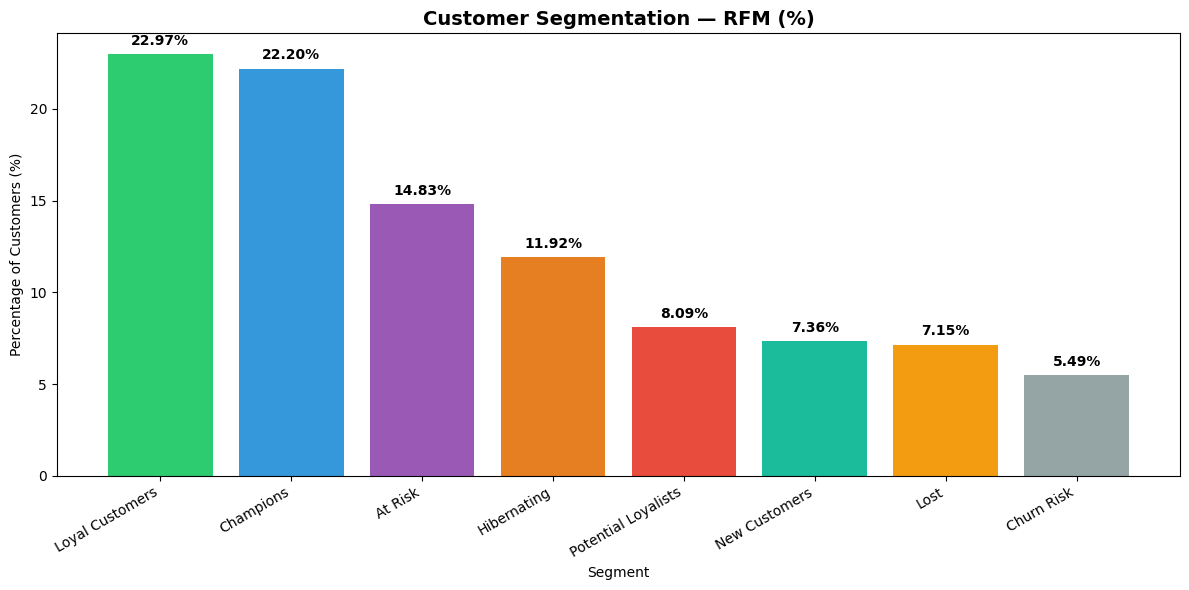

In [52]:
# Segment Bar Chart (Percentage)
# Calculate percentage distribution of each customer segment
seg = rfm['Segment'].value_counts(normalize=True).mul(100).round(2).reset_index()
seg.columns = ['Segment', 'Percentage']

# Define custom colors for the bars
colors = ['#2ecc71','#3498db','#9b59b6','#e67e22',
          '#e74c3c','#1abc9c','#f39c12','#95a5a6']

# Create the bar chart
plt.figure(figsize=(12,6))
bars = plt.bar(seg['Segment'], seg['Percentage'],
               color=colors[:len(seg)])

# Add percentage labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{bar.get_height():.2f}%",
             ha='center', fontsize=10, fontweight='bold')

plt.title('Customer Segmentation — RFM (%)', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [53]:
# Check rows where Description is '??'
df_clean[df_clean['Description'] == '??']

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Quantity,UnitPrice,TotalPrice,Country,Description


# Market Basket Analysis

In [54]:
# Add a column to show number of items in each itemset

basket = df_clean[df_clean['Country'] == 'United Kingdom']

basket_matrix = (basket.groupby(['InvoiceNo','Description'])['Quantity'].sum().unstack().fillna(0) > 0)

print(f"Basket matrix: {basket_matrix.shape}")

frequent_itemsets = apriori(basket_matrix,
                             min_support=0.03,
                             use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)


rules = association_rules(frequent_itemsets,
                           metric='lift',
                           min_threshold=1.5)
rules = rules.sort_values('lift', ascending=False)   # Sort rules by highest lift (strongest relationships first)

print(f"Frequent itemsets: {len(frequent_itemsets)}")
print(f"Association rules: {len(rules)}")
print(rules[['antecedents','consequents','support','confidence','lift']].head(5).to_string())

Basket matrix: (16622, 3831)
Frequent itemsets: 126
Association rules: 48
                              antecedents                            consequents   support  confidence       lift
35       (STRAWBERRY CERAMIC TRINKET BOX)       (STRAWBERRY CERAMIC TRINKET POT)  0.030261         1.0  33.045726
34       (STRAWBERRY CERAMIC TRINKET POT)       (STRAWBERRY CERAMIC TRINKET BOX)  0.030261         1.0  33.045726
17  (JUMBO BAG SCANDINAVIAN BLUE PAISLEY)       (JUMBO BAG SCANDINAVIAN PAISLEY)  0.030622         1.0  32.656189
16       (JUMBO BAG SCANDINAVIAN PAISLEY)  (JUMBO BAG SCANDINAVIAN BLUE PAISLEY)  0.030622         1.0  32.656189
0     (WOOD S/3 CABINET ANT WHITE FINISH)  (3 DRAWER ANTIQUE WHITE WOOD CABINET)  0.032547         1.0  30.724584


# COHORT ANALYSIS

In [55]:
# EXPLANATION:
# Cohort analysis groups customers based on their first purchase month and tracks their activity over time to measure retention.

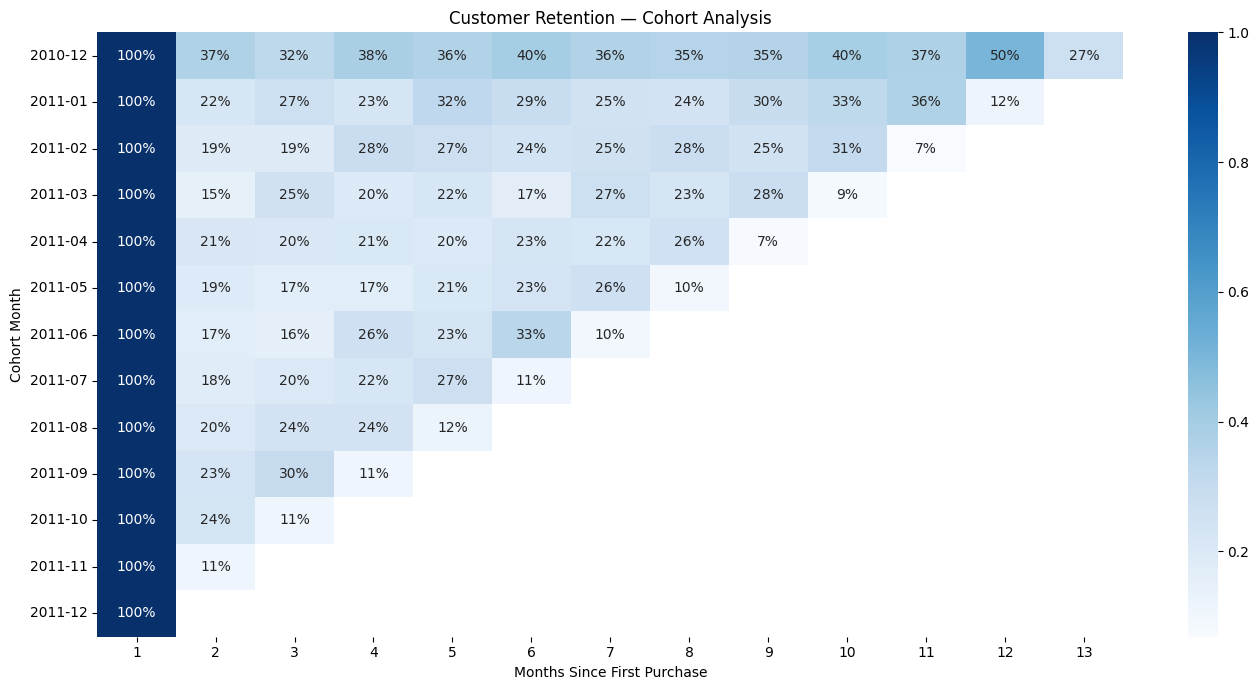

In [56]:
# Extract Invoice Month (year-month format)
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['CohortMonth']  = (df_clean.groupby('CustomerID')['InvoiceDate']
                             .transform('min').dt.to_period('M'))
# Identify Cohort Month (first purchase month for each customer)
df_clean['CohortIndex']  = (
    (df_clean['InvoiceMonth'].dt.year  - df_clean['CohortMonth'].dt.year) * 12 +
    (df_clean['InvoiceMonth'].dt.month - df_clean['CohortMonth'].dt.month) + 1
)

# Count unique customers for each cohort group and time period
cohort_data  = (df_clean.groupby(['CohortMonth','CohortIndex'])
                ['CustomerID'].nunique().reset_index())
cohort_table = cohort_data.pivot(index='CohortMonth',
                                  columns='CohortIndex',
                                  values='CustomerID')
retention    = cohort_table.divide(cohort_table.iloc[:,0], axis=0)

plt.figure(figsize=(14,7))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='Blues')
plt.title('Customer Retention — Cohort Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

# CLV Prediction (Lifetimes library)

In [57]:
# CLV Prediction
ltv_data = summary_data_from_transaction_data(
    df_clean,
    customer_id_col    = 'CustomerID',
    datetime_col       = 'InvoiceDate',
    monetary_value_col = 'TotalPrice',
    observation_period_end = df_clean['InvoiceDate'].max()
)
ltv_data = ltv_data[ltv_data['frequency'] > 0]

# BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(ltv_data['frequency'], ltv_data['recency'], ltv_data['T'])
ltv_data['predicted_purchases_90d'] = bgf.predict(
    90, ltv_data['frequency'], ltv_data['recency'], ltv_data['T']).round(2)

# Gamma-Gamma model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(ltv_data['frequency'], ltv_data['monetary_value'])
ltv_data['CLV_12months'] = ggf.customer_lifetime_value(
    bgf,
    ltv_data['frequency'], ltv_data['recency'],
    ltv_data['T'],         ltv_data['monetary_value'],
    time=12, freq='D').round(2)

print(f"CLV calculated for {len(ltv_data):,} customers")
print(ltv_data[['frequency','monetary_value',
                'predicted_purchases_90d','CLV_12months']].head(10))

CLV calculated for 2,783 customers
            frequency  monetary_value  predicted_purchases_90d  CLV_12months
CustomerID                                                                  
12347             6.0      605.655000                     1.49       3497.02
12348             3.0      261.480000                     0.92        960.20
12352             6.0      321.565000                     1.77       2196.57
12356             2.0      269.905000                     0.77        866.58
12358             1.0      523.200000                     0.93       2231.38
12359             3.0     2229.910000                     0.98       8686.00
12360             2.0      765.640000                     1.10       3483.63
12362             9.0      543.197778                     2.47       5138.59
12363             1.0      498.180000                     0.62       1422.74
12364             3.0      216.726667                     2.04       1767.63


In [58]:
# Merge CLV into RFM (CustomerID is already a column from Cell 3)
rfm_final = rfm.merge(
    ltv_data[['predicted_purchases_90d','CLV_12months']],
    left_on   = 'CustomerID',
    right_index = True,
    how = 'left'
)

rfm_final['predicted_purchases_90d'] = rfm_final['predicted_purchases_90d'].fillna(0)
rfm_final['CLV_12months']            = rfm_final['CLV_12months'].fillna(0)


In [59]:
# Check what columns exist in rfm_final
print(rfm_final.columns.tolist())
print(rfm_final.shape)

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_score', 'F_score', 'M_score', 'RFM_score', 'Segment', 'predicted_purchases_90d', 'CLV_12months']
(4337, 11)


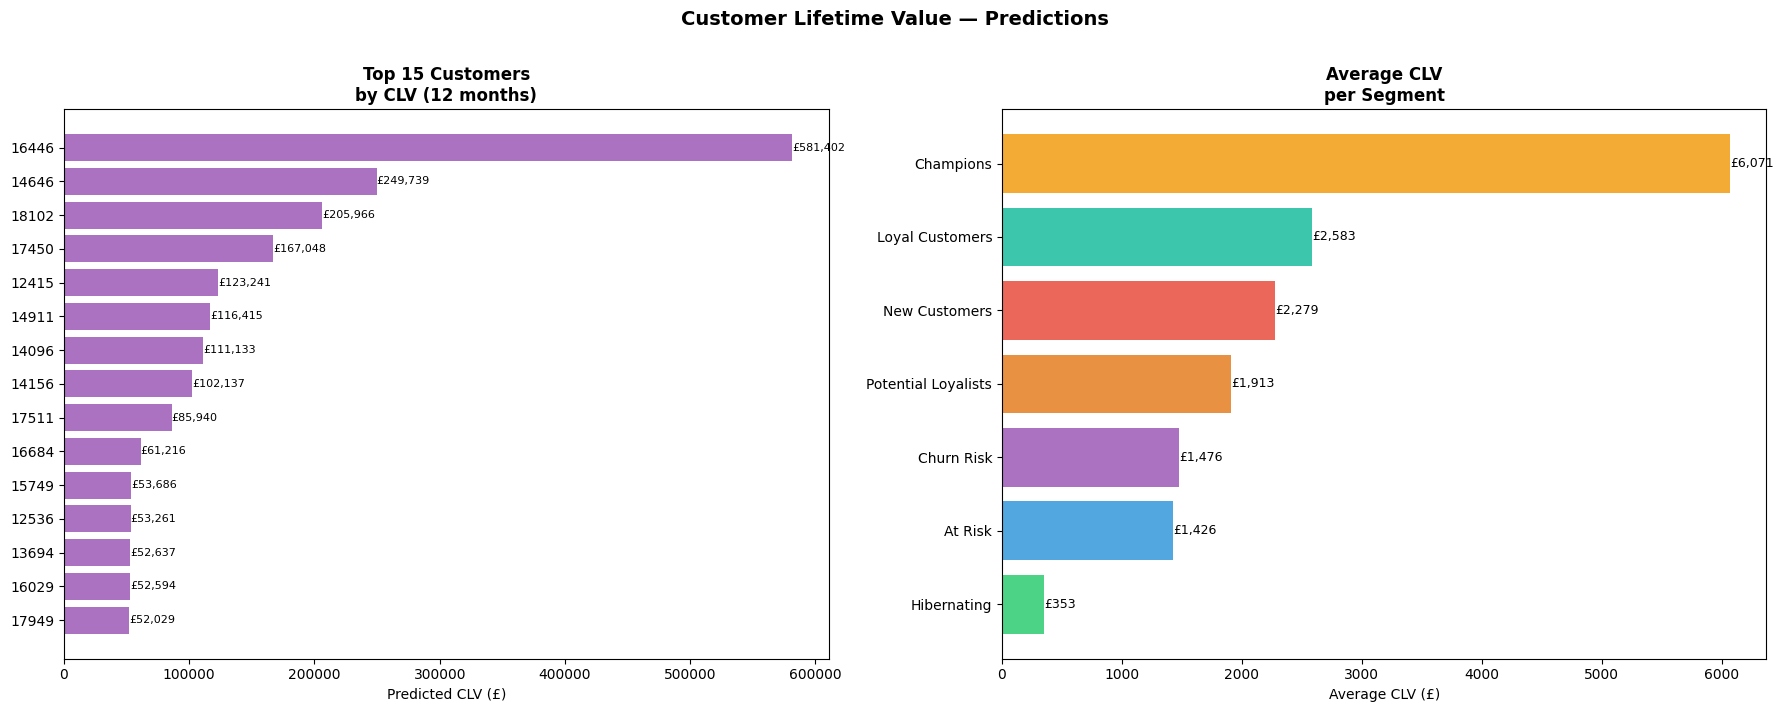

In [60]:
# ============================================================
# VISUALIZATION — CLV Prediction (3 charts)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Merge CLV back with segments for richer view
clv_seg = rfm_final[rfm_final['CLV_12months'] > 0].copy()

# --- Plot 1: Top 15 customers by CLV ---
top_clv = clv_seg.nlargest(15, 'CLV_12months')
axes[0].barh(top_clv['CustomerID'].astype(str),
             top_clv['CLV_12months'],
             color='#9b59b6', alpha=0.85)
axes[0].set_title('Top 15 Customers\nby CLV (12 months)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted CLV (£)')
axes[0].invert_yaxis()
for i, v in enumerate(top_clv['CLV_12months']):
    axes[0].text(v + 5, i, f'£{v:,.0f}', va='center', fontsize=8)

# --- Plot 2: Avg CLV per Segment ---
clv_by_seg = clv_seg.groupby('Segment')['CLV_12months'].mean().sort_values(ascending=True)
colors_seg = ['#2ecc71','#3498db','#9b59b6','#e67e22',
              '#e74c3c','#1abc9c','#f39c12','#95a5a6']
axes[1].barh(clv_by_seg.index, clv_by_seg.values,
             color=colors_seg[:len(clv_by_seg)], alpha=0.85)
axes[1].set_title('Average CLV\nper Segment', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Average CLV (£)')
for i, v in enumerate(clv_by_seg.values):
    axes[1].text(v + 1, i, f'£{v:,.0f}', va='center', fontsize=9)

plt.suptitle('Customer Lifetime Value — Predictions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# DATA VISUALIZATION

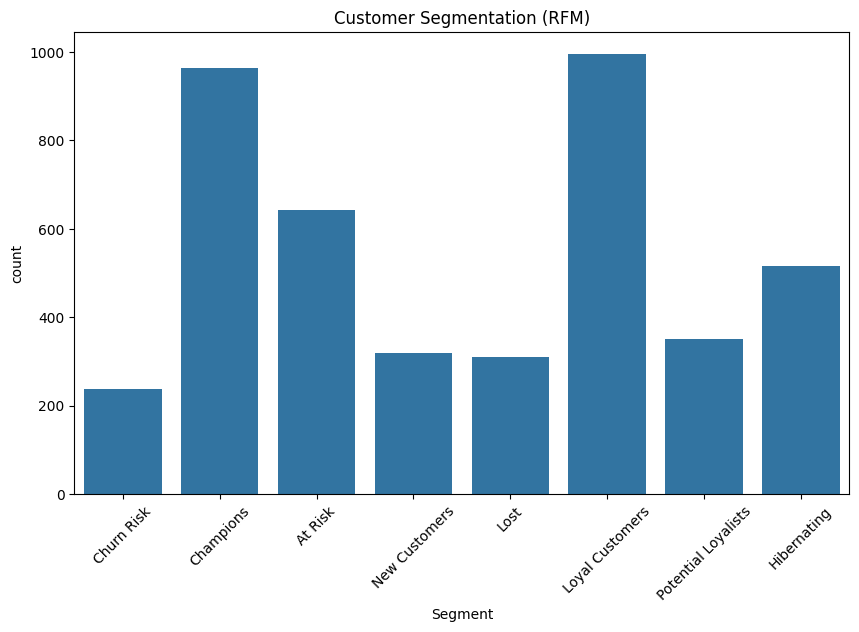

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot customer segment distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=45)
plt.title("Customer Segmentation (RFM)")
plt.show()

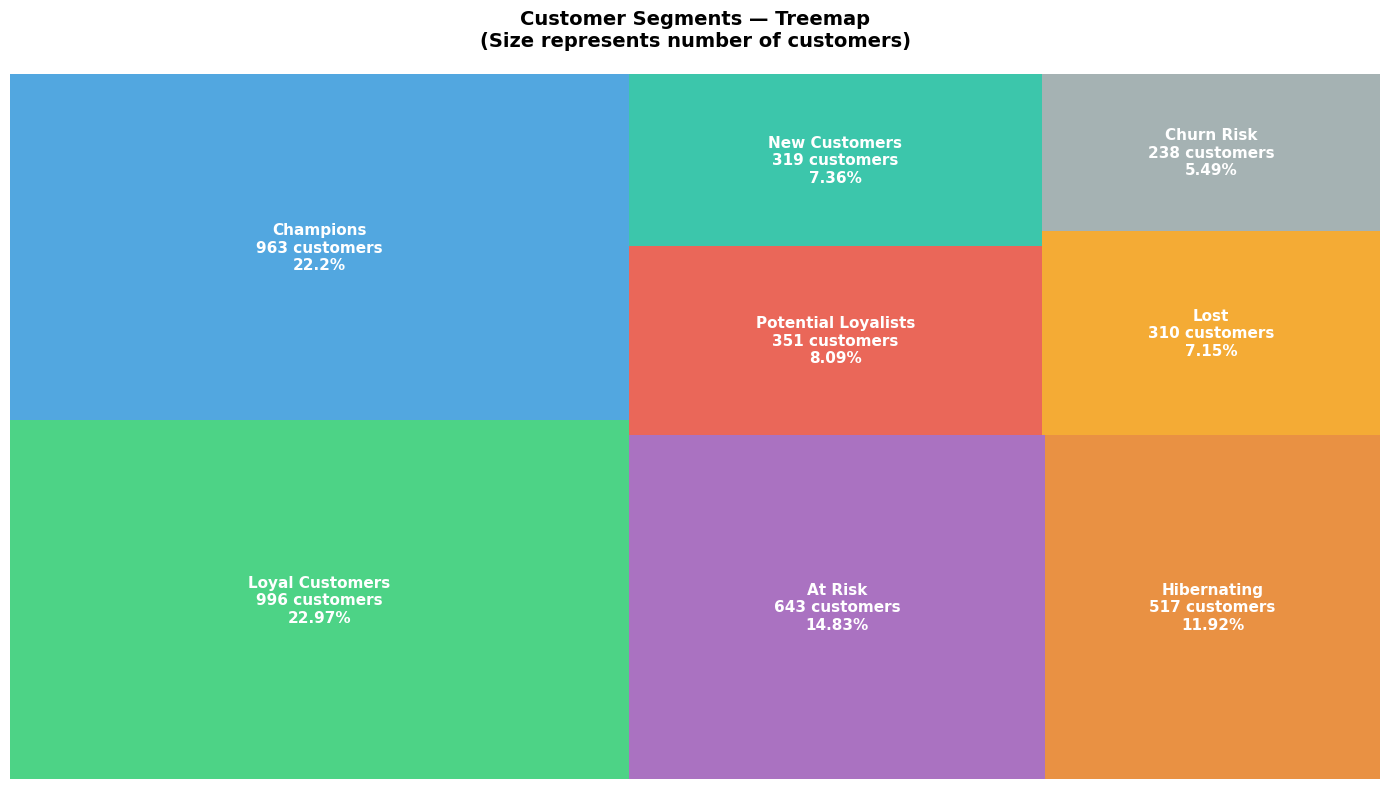

In [62]:
# Treemap (Size = Customer Count)

import squarify

seg = rfm['Segment'].value_counts().reset_index()
seg.columns = ['Segment', 'Count']
seg['Percentage'] = (seg['Count'] / seg['Count'].sum() * 100).round(2)
seg['Label'] = seg['Segment'] + '\n' + seg['Count'].astype(str) + ' customers\n' + seg['Percentage'].astype(str) + '%'

colors = ['#2ecc71','#3498db','#9b59b6','#e67e22',
          '#e74c3c','#1abc9c','#f39c12','#95a5a6']

plt.figure(figsize=(14, 8))
squarify.plot(
    sizes  = seg['Count'],
    label  = seg['Label'],
    color  = colors[:len(seg)],
    alpha  = 0.85,
    text_kwargs = {'fontsize': 11, 'fontweight': 'bold', 'color': 'white'}
)

plt.title('Customer Segments — Treemap\n(Size represents number of customers)',
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# DATA EXPORT

###  EXPORT DATA FOR POWER BI

In [63]:
# Merge & Export CSVs

# Merge CLV into RFM (CustomerID is already a column from Cell 3)
#rfm_final = rfm.merge(
#    ltv_data[['predicted_purchases_90d','CLV_12months']],
#    left_on   = 'CustomerID',
 #   right_index = True,
  #  how = 'left'
#)

#rfm_final['predicted_purchases_90d'] = rfm_final['predicted_purchases_90d'].fillna(0)
#rfm_final['CLV_12months']            = rfm_final['CLV_12months'].fillna(0)

# Export
rfm_final.to_csv("rfm_segments.csv",       index=False)
df_clean.to_csv("clean_retail_data.csv",   index=False)
rules.to_csv("market_basket_rules.csv",    index=False)

# Final verification
print("=" * 55)
print("EXPORT COMPLETE — COLUMN CHECK")
print("=" * 55)
for col in rfm_final.columns:
    filled = rfm_final[col].notna().sum()
    print(f"  {col:35s} {filled:,} rows filled")

EXPORT COMPLETE — COLUMN CHECK
  CustomerID                          4,337 rows filled
  Recency                             4,337 rows filled
  Frequency                           4,337 rows filled
  Monetary                            4,337 rows filled
  R_score                             4,337 rows filled
  F_score                             4,337 rows filled
  M_score                             4,337 rows filled
  RFM_score                           4,337 rows filled
  Segment                             4,337 rows filled
  predicted_purchases_90d             4,337 rows filled
  CLV_12months                        4,337 rows filled


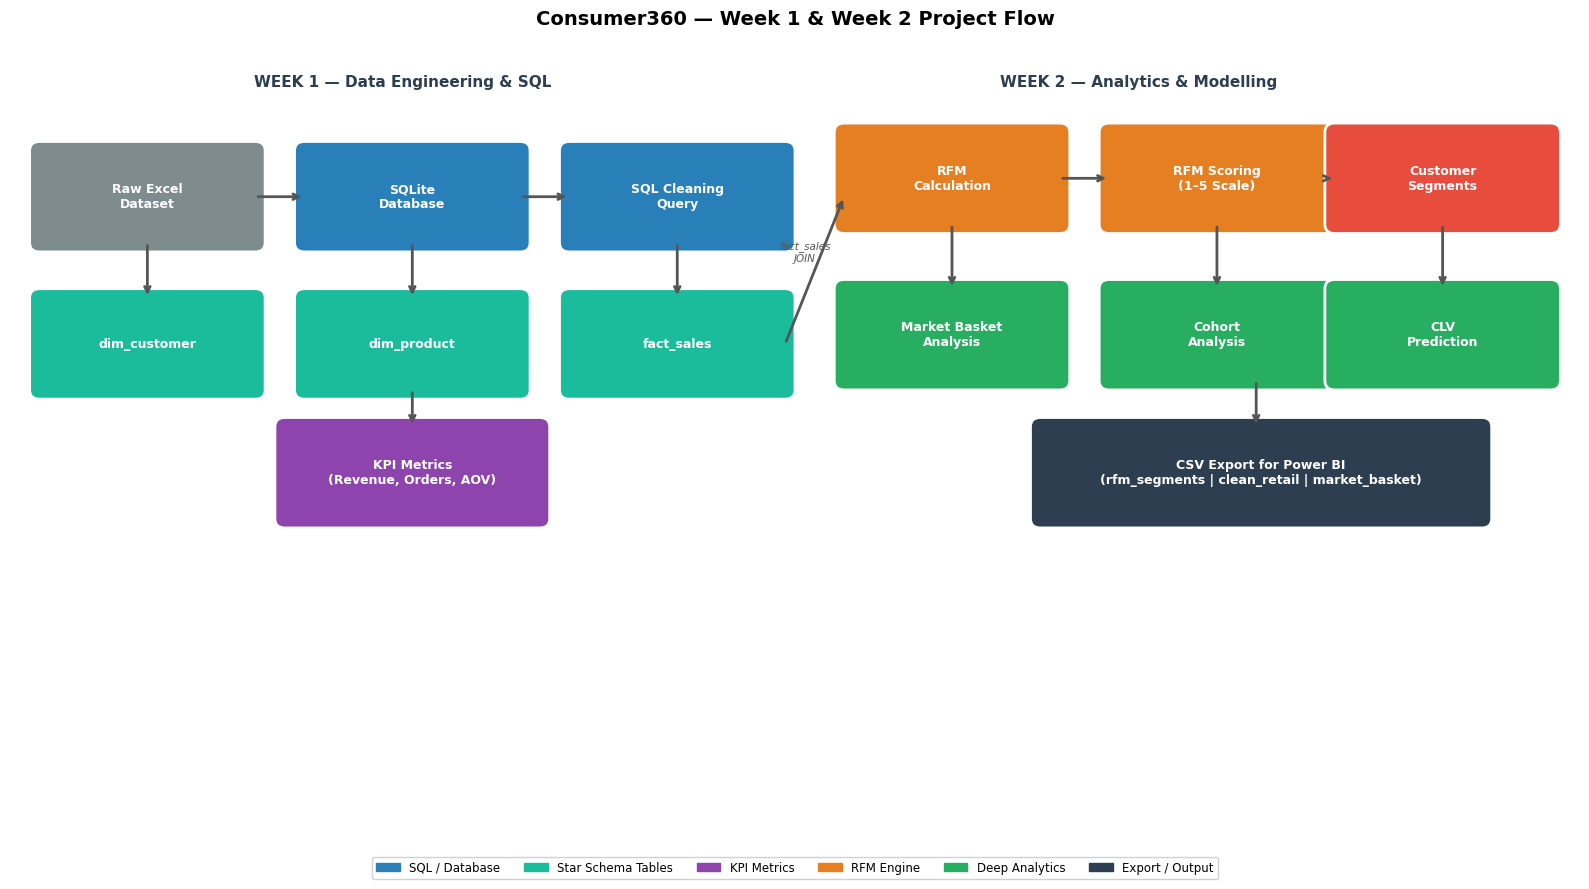

In [64]:
# Project Flow (Week 1 + Week 2)

import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    box = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle = 'round,pad=0.1',
        facecolor = color,
        edgecolor = 'white',
        linewidth = 2
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text,
            ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color='white', wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#555',
                        lw=2))

# WEEK 1 BOXES 
ax.text(4, 8.5, 'WEEK 1 — Data Engineering & SQL',
        ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

draw_box(ax, 0.3, 6.8, 2.2, 1.0, 'Raw Excel\nDataset',        '#7f8c8d')
draw_box(ax, 3.0, 6.8, 2.2, 1.0, 'SQLite\nDatabase',          '#2980b9')
draw_box(ax, 5.7, 6.8, 2.2, 1.0, 'SQL Cleaning\nQuery',       '#2980b9')
draw_box(ax, 0.3, 5.2, 2.2, 1.0, 'dim_customer',              '#1abc9c')
draw_box(ax, 3.0, 5.2, 2.2, 1.0, 'dim_product',               '#1abc9c')
draw_box(ax, 5.7, 5.2, 2.2, 1.0, 'fact_sales',                '#1abc9c')
draw_box(ax, 2.8, 3.8, 2.6, 1.0, 'KPI Metrics\n(Revenue, Orders, AOV)', '#8e44ad')

draw_arrow(ax, 2.5,  7.3, 3.0,  7.3)
draw_arrow(ax, 5.2,  7.3, 5.7,  7.3)
draw_arrow(ax, 1.4,  6.8, 1.4,  6.2)
draw_arrow(ax, 4.1,  6.8, 4.1,  6.2)
draw_arrow(ax, 6.8,  6.8, 6.8,  6.2)
draw_arrow(ax, 4.1,  5.2, 4.1,  4.8)

# WEEK 2 BOXES
ax.text(11.5, 8.5, 'WEEK 2 — Analytics & Modelling',
        ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

draw_box(ax, 8.5,  7.0, 2.2, 1.0, 'RFM\nCalculation',        '#e67e22')
draw_box(ax, 11.2, 7.0, 2.2, 1.0, 'RFM Scoring\n(1–5 Scale)', '#e67e22')
draw_box(ax, 13.5, 7.0, 2.2, 1.0, 'Customer\nSegments',       '#e74c3c')

draw_box(ax, 8.5,  5.3, 2.2, 1.0, 'Market Basket\nAnalysis',  '#27ae60')
draw_box(ax, 11.2, 5.3, 2.2, 1.0, 'Cohort\nAnalysis',         '#27ae60')
draw_box(ax, 13.5, 5.3, 2.2, 1.0, 'CLV\nPrediction',          '#27ae60')

draw_box(ax, 10.5, 3.8, 4.5, 1.0, 'CSV Export for Power BI\n(rfm_segments | clean_retail | market_basket)', '#2c3e50')

draw_arrow(ax, 10.7, 7.5, 11.2, 7.5)
draw_arrow(ax, 13.4, 7.5, 13.5, 7.5)
draw_arrow(ax, 9.6,  7.0, 9.6,  6.3)
draw_arrow(ax, 12.3, 7.0, 12.3, 6.3)
draw_arrow(ax, 14.6, 7.0, 14.6, 6.3)
draw_arrow(ax, 12.7, 5.3, 12.7, 4.8)

# CONNECTOR WEEK1 → WEEK2 
draw_arrow(ax, 7.9, 5.7, 8.5, 7.3)
ax.text(8.1, 6.6, 'fact_sales\nJOIN', fontsize=7.5,
        color='#555', ha='center', style='italic')

# LEGEND 
legend_items = [
    mpatches.Patch(color='#2980b9', label='SQL / Database'),
    mpatches.Patch(color='#1abc9c', label='Star Schema Tables'),
    mpatches.Patch(color='#8e44ad', label='KPI Metrics'),
    mpatches.Patch(color='#e67e22', label='RFM Engine'),
    mpatches.Patch(color='#27ae60', label='Deep Analytics'),
    mpatches.Patch(color='#2c3e50', label='Export / Output'),
]
ax.legend(handles=legend_items, loc='lower center',
          ncol=6, fontsize=8.5, framealpha=0.9,
          bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Consumer360 — Week 1 & Week 2 Project Flow',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()